<a href="https://colab.research.google.com/github/souhaylelhammadi/analytique-des-donn-es-et-informatique-d-cisionnelle/blob/main/ACP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Données
data = {
    "TP":[12,15,9,18,14,10],
    "Examen":[11,16,8,17,13,9],
    "Projet":[13,14,10,18,15,11],
    "Assiduite":[90,95,70,98,85,75]
}


df = pd.DataFrame(data)
df.index = [f'Etudiant{i+1}' for i in range(len(df))]

print(" Données originales")
print(df)

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("\n Données standardisées (moyenne=0, écart-type=1)")
print(X_scaled)



 Données originales
           TP  Examen  Projet  Assiduite
Etudiant1  12      11      13         90
Etudiant2  15      16      14         95
Etudiant3   9       8      10         70
Etudiant4  18      17      18         98
Etudiant5  14      13      15         85
Etudiant6  10       9      11         75

 Données standardisées (moyenne=0, écart-type=1)
[[-0.32732684 -0.39801488 -0.19011728  0.44357765]
 [ 0.65465367  1.09454091  0.19011728  0.93644171]
 [-1.30930734 -1.29354835 -1.33082093 -1.52787858]
 [ 1.63663418  1.39305207  1.71105548  1.23216015]
 [ 0.32732684  0.19900744  0.57035183 -0.04928641]
 [-0.98198051 -0.99503719 -0.95058638 -1.03501452]]


In [21]:
# ACP / PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Valeurs propres et variances
valeurs_propres = pca.explained_variance_
variance_expliquee = pca.explained_variance_ratio_ * 100
variance_cumulee = np.cumsum(variance_expliquee)

df_variance = pd.DataFrame({
    "Valeur propre": valeurs_propres,
    "Variance expliquée (%)": variance_expliquee,
    "Variance cumulée (%)": variance_cumulee
}, index=[f"PC{i+1}" for i in range(len(valeurs_propres))])

print("\n Variance expliquée par composante")
print(df_variance)





 Variance expliquée par composante
     Valeur propre  Variance expliquée (%)  Variance cumulée (%)
PC1       4.541007               94.604316             94.604316
PC2       0.177795                3.704059             98.308375
PC3       0.080148                1.669746             99.978121
PC4       0.001050                0.021879            100.000000


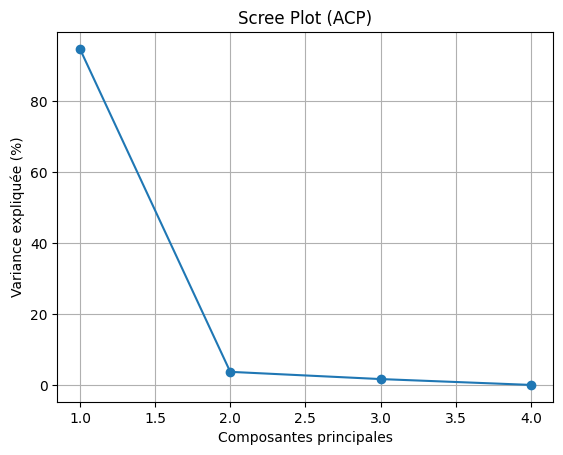

In [22]:

# Scree plot

plt.plot(
    range(1, len(valeurs_propres) + 1),
    variance_expliquee,
    marker='o'
)
plt.xlabel("Composantes principales")
plt.ylabel("Variance expliquée (%)")
plt.title("Scree Plot (ACP)")
plt.grid()
plt.show()

In [23]:
composantes= pd.DataFrame(pca.components_,columns=df.columns,index=[f'PC{i+1}' for i in range(len(df.columns))])
print("\n Composantes principales")
display(composantes)


 Composantes principales


,TP,Examen,Projet,Assiduite
PC1,0.511019,0.503859,0.495379,0.489475
PC2,-0.246215,0.160682,-0.624443,0.723623
PC3,0.183747,0.727040,-0.448703,-0.486124
PC4,0.802792,-0.437859,-0.404149,0.021624


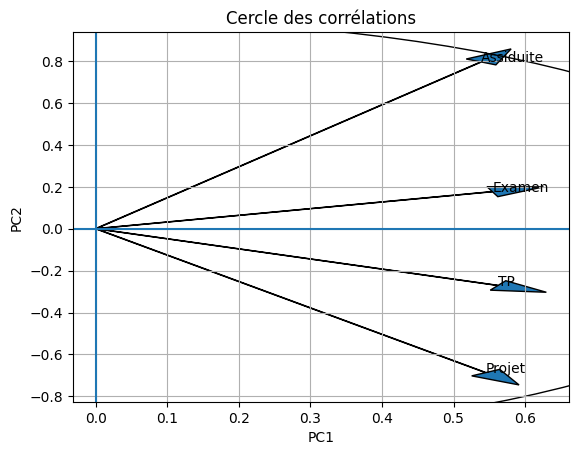

In [24]:

plt.figure()

for i in range(len(df.columns)):
    plt.arrow(0, 0,
              composantes.iloc[0, i] * 1.1,
              composantes.iloc[1, i] * 1.1,
              head_width=0.05)

    plt.text(composantes.iloc[0, i] * 1.1,
             composantes.iloc[1, i] * 1.1,
             df.columns[i])

circle = plt.Circle((0, 0), 1, fill=False)
plt.gca().add_artist(circle)

plt.axhline(0)
plt.axvline(0)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Cercle des corrélations")
plt.grid()
plt.show()

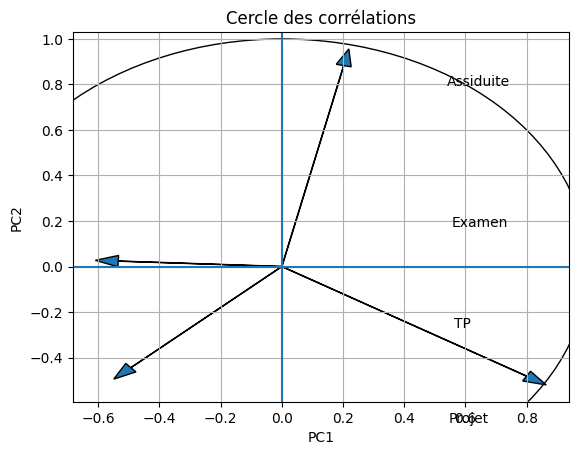

In [26]:

plt.figure()

for i in range(len(df.columns)):
    plt.arrow(0, 0,
              composantes.iloc[2, i] * 1.1,
              composantes.iloc[3, i] * 1.1,
              head_width=0.05)

    plt.text(composantes.iloc[0, i] * 1.1,
             composantes.iloc[1, i] * 1.1,
             df.columns[i])

circle = plt.Circle((0, 0), 1, fill=False)
plt.gca().add_artist(circle)

plt.axhline(0)
plt.axvline(0)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Cercle des corrélations")
plt.grid()
plt.show()

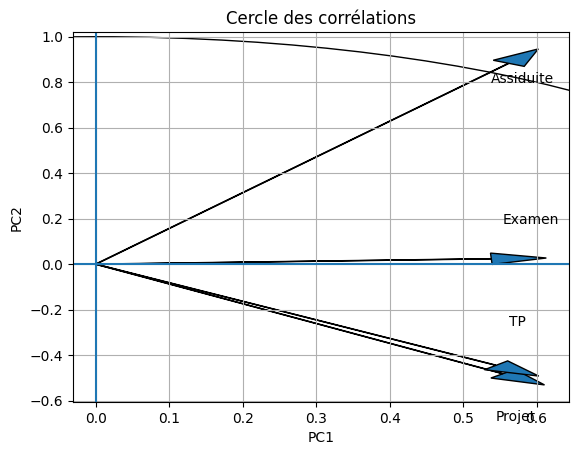

In [27]:

plt.figure()

for i in range(len(df.columns)):
    plt.arrow(0, 0,
              composantes.iloc[0, i] * 1.1,
              composantes.iloc[3, i] * 1.1,
              head_width=0.05)

    plt.text(composantes.iloc[0, i] * 1.1,
             composantes.iloc[1, i] * 1.1,
             df.columns[i])

circle = plt.Circle((0, 0), 1, fill=False)
plt.gca().add_artist(circle)

plt.axhline(0)
plt.axvline(0)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Cercle des corrélations")
plt.grid()
plt.show()

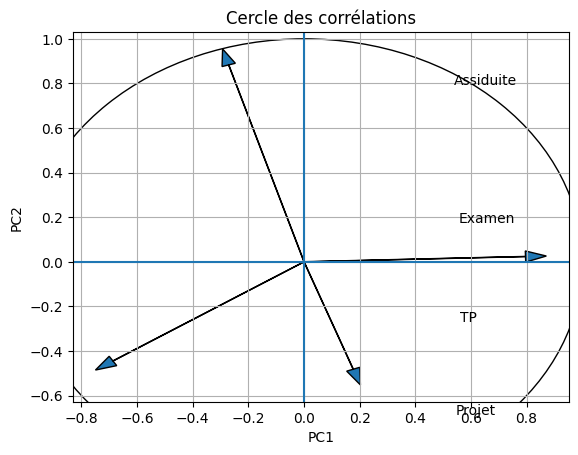

In [28]:

plt.figure()

for i in range(len(df.columns)):
    plt.arrow(0, 0,
              composantes.iloc[1, i] * 1.1,
              composantes.iloc[3, i] * 1.1,
              head_width=0.05)

    plt.text(composantes.iloc[0, i] * 1.1,
             composantes.iloc[1, i] * 1.1,
             df.columns[i])

circle = plt.Circle((0, 0), 1, fill=False)
plt.gca().add_artist(circle)

plt.axhline(0)
plt.axvline(0)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Cercle des corrélations")
plt.grid()
plt.show()

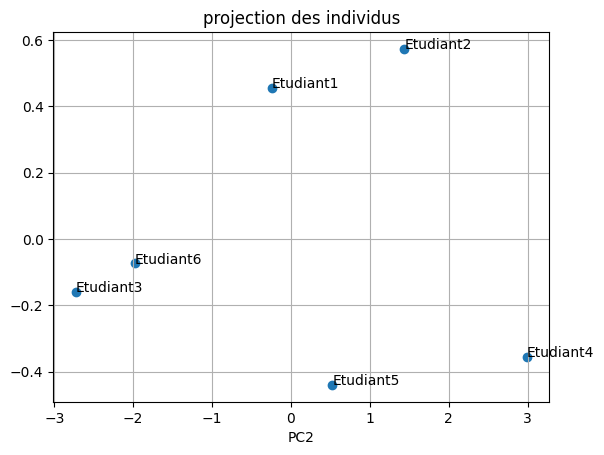

In [30]:
plt.figure()
plt.scatter(X_pca[:,0],X_pca[:,1])
for i ,label in enumerate(df.index):
  plt.annotate(label,(X_pca[i,0],X_pca[i,1]))
plt.xlabel("PC1")
plt.xlabel("PC2")
plt.title('projection des individus')
plt.grid()
plt.show()